In [1]:
import random
import statistics
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Ask for number of rounds
N = int(input("Enter the number of rounds: "))

In [3]:
# Player 1
R1 = int(input("Player 1 Rocks: "))
P1 = int(input("Player 1 Papers: "))
S1 = int(input("Player 1 Scissors: "))

# Player 2
R2 = int(input("Player 2 Rocks: "))
P2 = int(input("Player 2 Papers: "))
S2 = int(input("Player 2 Scissors: "))

In [4]:
# Create player tuples
player1 = (R1, P1, S1)
player2 = (R2, P2, S2)

In [5]:
score1 = R1 + P1 + S1
score2 = R2 + P2 + S2

In [11]:
# Check if moves and rounds are consistent

if R1 + P1 + S1 != N or R2 + P2 + S2 != N:
    print("Error: The total number of moves for each player must equal the number of rounds.")

In [12]:
# Generate sequences for both players

def generate_sequence(weights):
    R, P, S = weights

    sequence = ['R'] * R + ['P'] * P + ['S'] * S
    random.shuffle(sequence)

    return sequence

In [13]:
# Call separate functions to generate sequences for both players

seq1 = generate_sequence(player1)
seq2 = generate_sequence(player2)

In [14]:
# Play the game and calculate scores

def play_game(seq1, seq2):
    score1 = 0
    score2 = 0

    for m1, m2 in zip(seq1, seq2):

        # draw
        if m1 == m2:
            continue

        # Player 1 wins
        if (m1 == 'R' and m2 == 'S') or (m1 == 'S' and m2 == 'P') or (m1 == 'P' and m2 == 'R'):
            score1 += 1
            score2 -= 1
        else: # Player 2 wins
            score1 -= 1
            score2 += 1

    return score1, score2

In [15]:
def run_simulations(player1, player2, N=10000):

    scores1 = []
    scores2 = []

    best_score1 = float('-inf')
    best_seq1 = None

    best_score2 = float('-inf')
    best_seq2 = None

    freq1 = {}
    freq2 = {}

    for _ in range(N):

        seq1 = generate_sequence(player1)
        seq2 = generate_sequence(player2)

        score1, score2 = play_game(seq1, seq2)

        scores1.append(score1)
        scores2.append(score2)

        # track Player 1 best
        if score1 > best_score1:
            best_score1 = score1
            best_seq1 = seq1.copy()

        # track Player 2 best
        if score2 > best_score2:
            best_score2 = score2
            best_seq2 = seq2.copy()

        # frequency tracking
        key1 = tuple(seq1)
        key2 = tuple(seq2)

        freq1[key1] = freq1.get(key1, 0) + 1
        freq2[key2] = freq2.get(key2, 0) + 1

    return scores1, scores2, best_seq1, best_score1, best_seq2, best_score2, freq1, freq2

In [16]:
# Run simulation for both players
scores1, scores2, *_ = run_simulations(player1, player2)

# Calculate average scores
print("Player 1 average: ", sum(scores1) / len(scores1))
print("Player 2 average: ", sum(scores2) / len(scores2))

Player 1 average:  -1.0
Player 2 average:  1.0


In [17]:
# Calculate standard deviation of scores
print("Player 1 standard deviation: ", statistics.stdev(scores1))
print("Player 2 standard deviation: ", statistics.stdev(scores2))

Player 1 standard deviation:  0.0
Player 2 standard deviation:  0.0


In [18]:
# calculate score distribution for both players
print("Player 1 score distribution: ", Counter(scores1))
print("Player 2 score distribution: ", Counter(scores2))

Player 1 score distribution:  Counter({-1: 10000})
Player 2 score distribution:  Counter({1: 10000})


In [19]:
# Verify best sequences and scores
scores1, scores2, best_seq1, best_score1, best_seq2, best_score2, *_ = run_simulations(player1, player2)

print("Best P1 sequence:", best_seq1)
print("Best P1 score:", best_score1)

print("Best P2 sequence:", best_seq2)
print("Best P2 score:", best_score2)

Best P1 sequence: ['R', 'P']
Best P1 score: -1
Best P2 sequence: ['P', 'P']
Best P2 score: 1


In [20]:
# Check frequency of best sequences
scores1, scores2, best_seq1, best_score1, best_seq2, best_score2, freq1, freq2 = run_simulations(player1, player2)

print(freq1[tuple(best_seq1)])
print(freq2[tuple(best_seq2)])

5045
10000


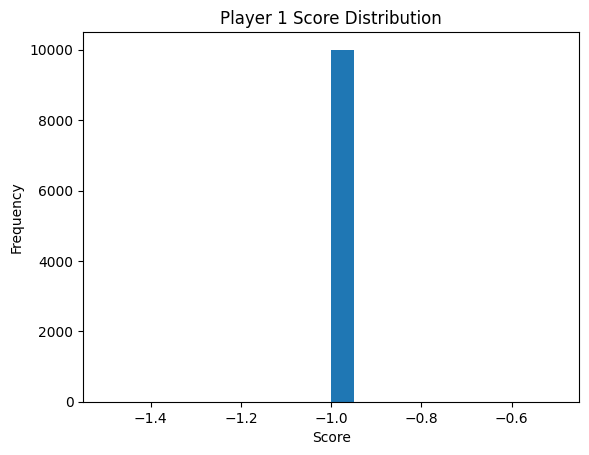

In [21]:
# Histogram of scores for Player 1

plt.hist(scores1, bins=20)
plt.title("Player 1 Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

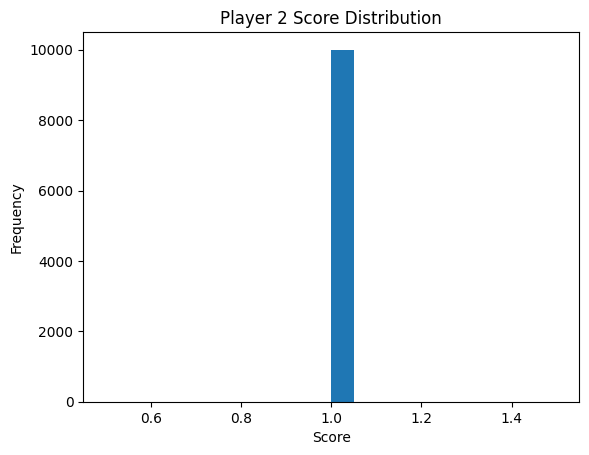

In [22]:
# Histogram of scores for Player 2

plt.hist(scores2, bins=20)
plt.title("Player 2 Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [23]:
# Create a table using Pandas to display the best scores, sequences, and frequencies for both players

table = pd.DataFrame({
    "Player": ["Player 1", "Player 2"],
    "Best Score": [best_score1, best_score2],
    "Best Sequence": [best_seq1, best_seq2],
    "Frequency": [
        freq1[tuple(best_seq1)],
        freq2[tuple(best_seq2)]
    ]
})

print(table)

     Player  Best Score Best Sequence  Frequency
0  Player 1          -1        [R, P]       5045
1  Player 2           1        [P, P]      10000


In [24]:
# Create modified sequences by swapping the first two moves of the best sequences

def swap_first_two(seq):
    new_seq = seq.copy()
    new_seq[0], new_seq[1] = new_seq[1], new_seq[0]
    return new_seq

In [25]:
# Test variations of the best sequences by swapping the first two moves and calculating their scores

base_score = play_game(best_seq1, best_seq2)[0]

scores = []
labels = []

for i in range(10):
    modified = best_seq1.copy()
    
    # small random swap
    j = i % len(modified)
    modified[0], modified[j] = modified[j], modified[0]

    score = play_game(modified, best_seq2)[0]
    
    scores.append(score)
    labels.append(i)

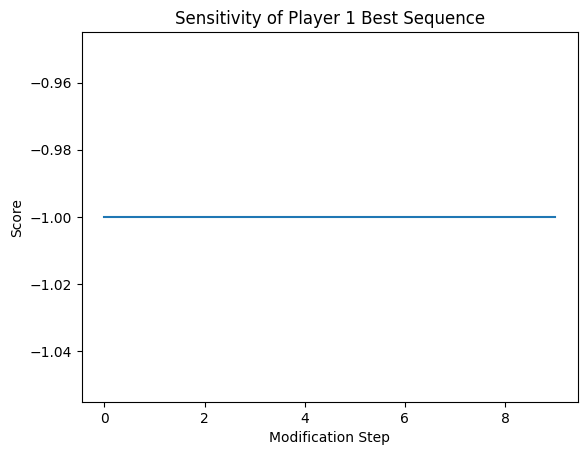

In [26]:
# Create a plot line graph to visualize the scores of the modified sequences

plt.plot(labels, scores)
plt.title("Sensitivity of Player 1 Best Sequence")
plt.xlabel("Modification Step")
plt.ylabel("Score")
plt.show()

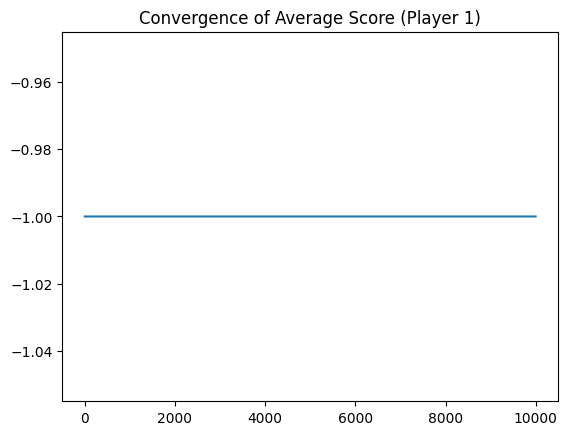

In [27]:
# Show convergence for player 1's best sequence by running multiple simulations and plotting the average score over time

avg_scores = []
temp = []

for i in range(1, len(scores1)):
    temp.append(scores1[i])
    avg_scores.append(sum(temp)/len(temp))

plt.plot(avg_scores)
plt.title("Convergence of Average Score (Player 1)")
plt.show()

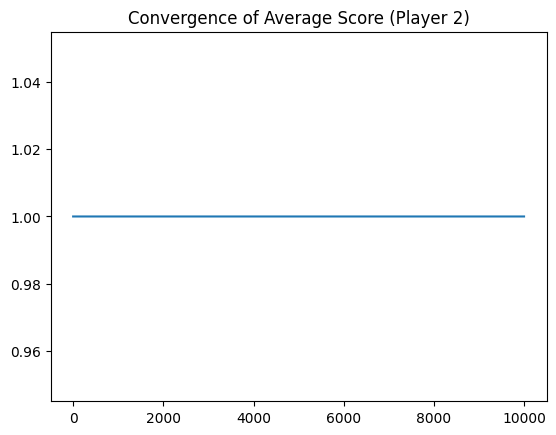

In [29]:
# Show convergence for player 2's best sequence by running multiple simulations and plotting the average score over time

avg_scores = []
temp = []

for i in range(1, len(scores2)):
    temp.append(scores2[i])
    avg_scores.append(sum(temp)/len(temp))

plt.plot(avg_scores)
plt.title("Convergence of Average Score (Player 2)")
plt.show()